# General python scientific array and plot comparison with matlab

## Objective
Using numpy and start with 1D, 2D matrix to demonstrate matlab like behavior, using `f06_matlab_python_numerics.mlx` for comparison

### Target

Compare NumPy array operations with MATLAB matrix operations, while identifying important syntax and behavior differences
1. be able to follow the NumPy arrays webpage [here!](https://lectures.scientific-python.org/intro/numpy/array_object.html)
2. use NumPy to demostrate basic signal processing and control matrix manipulation
3. program numerical algorithms such as Extended Kalman Filter usage for future research and thesis

In [29]:
# check environment
import sys
import os
from pathlib import Path

print("Python version:", sys.version)
print("Python excutable:", sys.executable)
print("Working directory:",Path.cwd())


Python version: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
Python excutable: c:\Users\itsyu\GitHub\learning\.venv\Scripts\python.exe
Working directory: c:\Users\itsyu\GitHub\learning\matlab_python


Now we officially import NumPy as np
note that np is now a alis that is used to call Numpy module
instead of numpy.function(argument), we are going to use np.def(input, keys)

In [30]:
import numpy as np
print("NumPy version:", np.__version__)
# np is now the conventional alias for the NumPy module.
# Instead of writing:
# numpy.array(...)

# we can write:
# np.array(...)

NumPy version: 2.5.1


## Exercise 1 - creating matrix and checking sizes
Use this exercise to familiarize with all the variable names and compare the command that is used in MATLAB

###  standard m-k-s 2nd order system model intention
Suppose we'd like to numerically simulate a mechanical 2nd order system

- m = 1.0 [kg]
- c = 0.5 [N s/m]
- k = 1.0 [N/m]

the standard eqaution from Newton's law with input forct $u(t)$ [N] is:

$$
m\ddot{x}(t) + c\dot{x}(t) + kx(t) = u(t)
$$

And using $x_1 = x(t)$, along with $x_2 = \dot{x}(t)$, it is standard to have

$$
\dot{x}_1 = x_2
$$

and

$$
\dot{x}_2
= -\frac{k}{m}x_1
  -\frac{c}{m}x_2
  +\frac{1}{m}u
$$

$$
\begin{bmatrix}
\dot{x}_1 \\
\dot{x}_2
\end{bmatrix}
=
\begin{bmatrix}
0 & 1 \\
-\frac{k}{m} & -\frac{c}{m}
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
+
\begin{bmatrix}
0 \\
\frac{1}{m}
\end{bmatrix}
u
$$

And if we define and made sure our system has an encoder that can track angle and angular velocity:

$$
y =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
=
\mathbb{I}
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
+ 0 * u
$$

where $\mathbb{A}$, $\mathbb{B}$, $\mathbb{C}$, and $\mathbb{D}$ are

$$ \mathbb{A} = 
\begin{bmatrix}
0 & 1\\
-k/m & -c/m
\end{bmatrix}
$$

$$ \mathbb{B} = 
\begin{bmatrix}
0 \\
1/m
\end{bmatrix}
$$

$$ \mathbb{C} = \mathbb{I} =
\begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix}
$$
and 

$$ \mathbb{D} = 
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

In [31]:
a = np.array([0, 1, 2, 3])

print(a)
print("the numeric type of variable a is:",type(a))

print("the dimension of a is:", a.ndim)
print("the shape of a is:", a.shape)
print("the length of a is:", len(a))

# let us try more general way
m = 1
c = 0.5
k = 1

A = np.array([
    [0, 1],
    [-k/m, -c/m]
    ])

print(A)
print("the dimension of A is:", A.ndim)
print("the shape of A is:", A.shape)
print("the length of A is:", len(A))

[0 1 2 3]
the numeric type of variable a is: <class 'numpy.ndarray'>
the dimension of a is: 1
the shape of a is: (4,)
the length of a is: 4
[[ 0.   1. ]
 [-1.  -0.5]]
the dimension of A is: 2
the shape of A is: (2, 2)
the length of A is: 2


## Exercise 2 - using element wise opeartion vs standard operation
| Operation | MATLAB | NumPy |
|---|---|---|
| Element-wise multiply | `A .* B` | `A * B` |
| Matrix multiply | `A * B` | `A @ B` |

### Target
1. compare to matlab
2. make sure it is mathematically correct and matlab version changes

In [32]:
B = np.array([
    [0],
    [1/m]
])

print(B)
print("the dimension of B is:", B.ndim)
print("the shape of B is:", B.shape)
print("the length of B is:", len(B))

C = np.zeros((2,2))
print(C)

C = np.ones((2,2))
print(C)

C = np.eye(2)
print(C)

print(A * C)

print(A @ C)

D = np.zeros((2,1))
print(D)

[[0.]
 [1.]]
the dimension of B is: 2
the shape of B is: (2, 1)
the length of B is: 2
[[0. 0.]
 [0. 0.]]
[[1. 1.]
 [1. 1.]]
[[1. 0.]
 [0. 1.]]
[[ 0.   0. ]
 [-0.  -0.5]]
[[ 0.   1. ]
 [-1.  -0.5]]
[[0.]
 [0.]]


let us use the same initial condition for numpy

In [33]:
x0 = np.array([
    [3.0],
    [-0.2]
    ])

print("initial position:",x0[0,0])      # note that this is different from matlab
print("initial velocity:",x0[1,0])

initial position: 3.0
initial velocity: -0.2


We'll compare with matlab. Since our numerical simulation is setup the same, it should be the same output.

In MATLAB, dimensions tend to remain matrices. In NumPy, an integer index removes a dimension; a slice preserves it. For control/EKF code, that is worth understanding very well.

In [34]:
dt = 0.01
t = np.linspace(0, 10, int(10/dt)+1)

print("the starting simulation time is:",t[0],"ends with",t[-1])
print("fixed time step of",dt,"having",len(t),"steps")

# initialize states and outputs
x = np.zeros((2,len(t)))
y = np.zeros((2,len(t)))

u = np.zeros((1,len(t)))    # input throughout simulation time
print("input control variable along time is size:", u.shape)
# initial condition
#x[:,0] = x0

print("state retainer along time is size:", x.shape)
print("the initial state is size:", x0.shape)

print("check first state without slice:", x[:,0])
print("becasue the shape is only:", x[:,0].shape)

print("to find the slice of some state:", x[:,0:1])
print("then the shape is true for such slice:", x[:,0:1].shape)

# equation to input the initial state and the initial output
x[:,0:1] = x0
y[:,0:1] = C @ x0 + D @ u[:,0:1]

#print(x[0])
#print(y[0])



the starting simulation time is: 0.0 ends with 10.0
fixed time step of 0.01 having 1001 steps
input control variable along time is size: (1, 1001)
state retainer along time is size: (2, 1001)
the initial state is size: (2, 1)
check first state without slice: [0. 0.]
becasue the shape is only: (2,)
to find the slice of some state: [[0.]
 [0.]]
then the shape is true for such slice: (2, 1)


## Exercise 3 - For loop with scientific dynamics equation iteration for integration

Now that all the "pre-dined" state and output matrix is ready for iteration, we can use the dynamics equation like in matlab exercise to find the "same solution"

### Careful the index difference

*most important difference*
 - python numpy.array is A[:,:] by index, not by slice
 - to gather all the sliced column A[:,0:1] takes the column 0 while preserving the second dimension
 - to get one slice column x[0,0:1] will have shape (1,)
 - x[i,:] will have shape (1,)

A matrix [[ 0.   1. ]
 [-1.  -0.5]]
B matrix [[0.]
 [1.]]
C matrix [[1. 0.]
 [0. 1.]]
D matrix [[0.]
 [0.]]
index: 1 time: 0.01
index: 2 time: 0.02
index: 3 time: 0.03
index: 4 time: 0.04


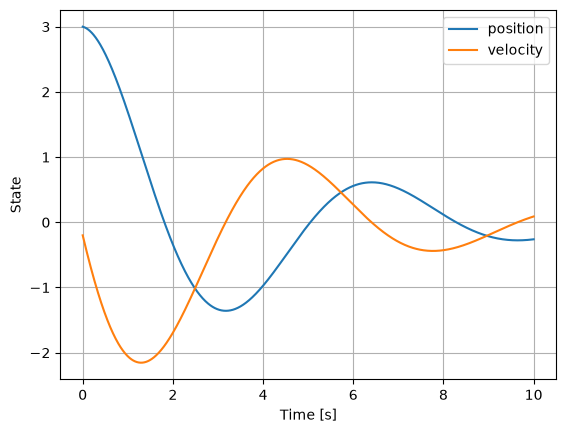

In [35]:
# last check 
print("A matrix", A)
print("B matrix", B)
print("C matrix", C)
print("D matrix", D)

#print(dt)

for i, ti in enumerate(t[1:], start=1):
    if i < 5:
        print("index:", i, "time:", ti)

    x_dot = A @ x[:,i-1:i] + B @ u[:,i-1:i]

    x[:,i:i+1] = x[:,i-1:i] + dt* x_dot
    y[:,i:i+1] = C @ x[:,i:i+1] + D @ u[:,i:i+1]

# now we import plot
import matplotlib.pyplot as plt

plt.plot(t, x[0, :], label="position")
plt.plot(t, x[1, :], label="velocity")

plt.xlabel("Time [s]")
plt.ylabel("State")
plt.legend()
plt.grid()

plt.show()


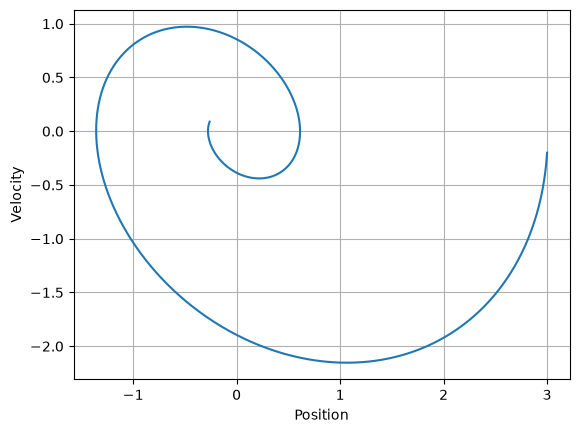

In [36]:
plt.plot(x[0, :], x[1, :])

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.grid()
plt.show()

## Exercise 4 - using ode45 like in matlab to solve initial value problem

This for loop earlier is the same as the matlab for loop in intergrating our dynamics equation.

It is more common to use a Ordinary Differential Equation solver in scientific numerical computation.

Please refer to matlab exercise 06

$$
m\ddot{x} + c\dot{x} + k x = u(t)
$$
where $u(t) = A \sin(\omega t)$
as we have $A=0.5$, $\omega = 2 \pi f$, with our case having $f=1$ Hertz

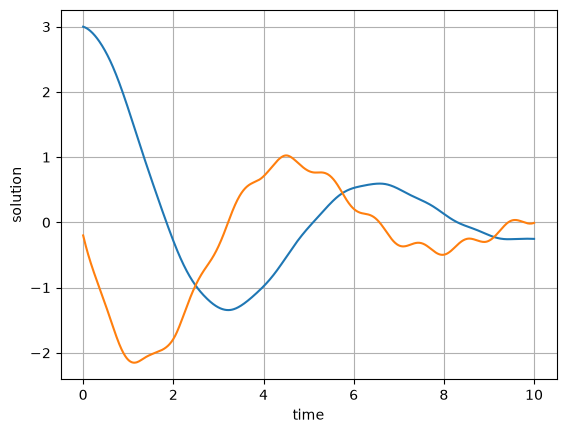

In [39]:
# import ODE solver from SciPy
from scipy.integrate import solve_ivp

# forced input frequency
f = 1  # Hz

# state equation: x_dot = A*x + B*u(t)
def state_eq(t, x):
    u_t = 0.5 * np.sin(2 * np.pi * f * t)
    return A @ x + B.flatten() * u_t

# solve the state equation
sol = solve_ivp(
    state_eq,
    [t[0], t[-1]],
    x0.flatten(),
    t_eval=t
)

# extract time and states
t_ode = sol.t
x_ode = sol.y

plt.plot(t_ode, x_ode[0, :], label="position")
plt.plot(t_ode, x_ode[1, :], label="velocity")

plt.xlabel("time")
plt.ylabel("solution")
plt.grid()
plt.show()

## Exercise 5 - Export .mat file for use later in Simulink modeling for comparison

using the previous e05_python_matlab_io.ipynb example, we remember to export the now fixed A, B, C, and D dynamics-output equation values for use in matlab

saved as "statspace_data.mat" that matlab can directly import

In [43]:
from scipy.io import savemat

ss_data = {
    "A" : A,
    "B" : B,
    "C" : C,
    "D" : D
}

filename = "statespace_data.mat"
savemat(filename, ss_data)
print(f"{filename} is logged")

statespace_data.mat is logged
